### 1. Dataset Exploration

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd

In [2]:
relationships = pd.read_csv("train_relationships.csv")
print("Shape:", relationships.shape)
relationships.head()

Shape: (3598, 2)


,p1,p2
0,F0002/MID1,F0002/MID3
1,F0002/MID2,F0002/MID3
2,F0005/MID1,F0005/MID2
3,F0005/MID3,F0005/MID2
4,F0009/MID1,F0009/MID4


In [3]:
# every row already means "these two are related. and (Person A ↔ Person B)   ., Not image pairs.
# so trat like
# p1            p2            is_related
# F0002/MID1    F0002/MID3    1
# F0002/MID2    F0002/MID3    1
# F0005/MID1    F0005/MID2    1

In [4]:
#all rows = positive

# Why do we need to generate negative pairs?
# "train_relationships.csv contains only positive (related) person pairs. A binary classification model needs examples 
# of both classes (related = 1 and unrelated = 0).Therefore, we generate negative pairs by pairing people from 
# different families, since people from different families are guaranteed to be unrelated."

In [5]:
# But can the model train on this?  No.
# Because neural networks don't understand text like "F0002/MID1".
# They need actual images.
# So our next question is:
# "Where is the image of F0002/MID1?"
# That answer is inside the folder structure.

In [6]:
#Explore the Folder Structure
#how many unique families are available for training and for generating negative pairs.
import os
from pathlib import Path

train_path = Path("data/train")
families = os.listdir(train_path)
print("Total Families:", len(families))   #Each folder is one family

Total Families: 470


In [7]:
#Count Total People  (Person A->Person B) : So we must know How many unique people exist?
people = 0
for family in families:
    people += len(os.listdir(train_path/family))
print("Total People:", people)

Total People: 2318


In [8]:
#Count Images
images = 0
for family in families:
    family_path = train_path / family
    for member in os.listdir(family_path):
        member_path = family_path / member
        images += len(os.listdir(member_path))
print("Total Images:", images)

# Why?
# Because we need to know
# How much image data do we actually have?

Total Images: 12379


In [9]:
#Random Family
import random
family = random.choice(families)

print(family)
print(os.listdir(train_path / family))

F0360
['MID1', 'MID2', 'MID3', 'MID4', 'MID5', 'MID6']


In [10]:
# Random Person
person = random.choice(os.listdir(train_path / family))
print(person)
print(os.listdir(train_path / family / person))

MID2
['P11234_face2.jpg', 'P12291_face1.jpg', 'P12292_face3.jpg', 'P12293_face1.jpg', 'P12295_face2.jpg', 'P12296_face3.jpg', 'P12297_face1.jpg', 'P12298_face1.jpg', 'P12303_face1.jpg', 'P12304_face2.jpg', 'P12308_face1.jpg', 'P12310_face1.jpg']


In [11]:
# Why did you inspect random families and random persons during EDA?
# "The dataset is hierarchical (Family → Person → Images). Since manually inspecting every folder isn't practical, 
# I sampled random families and persons to verify the directory structure, understand how images are organized, and 
# confirm that each MID directory corresponds to one individual with one or more face images.

In [12]:
# # summary
# The model will never see the folder names.
# Image
# ↓
# Embedding
# ↓
# Prediction

In [13]:
relationships.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3598 entries, 0 to 3597
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   p1      3598 non-null   object
 1   p2      3598 non-null   object
dtypes: object(2)
memory usage: 56.3+ KB


In [14]:
#No missing values. so  EDA DONE

In [15]:
import matplotlib.pyplot as plt
from PIL import Image

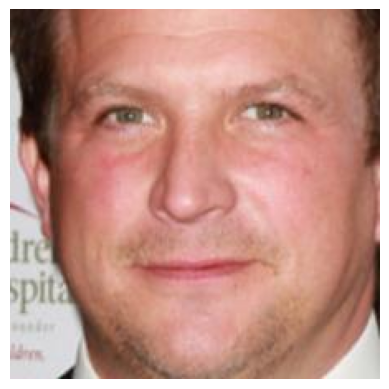

In [16]:
image_path = train_path / family / person / os.listdir(train_path / family / person)[0]
img = Image.open(image_path)
plt.imshow(img)
plt.axis("off")
plt.show()

In [17]:
# You displayed a random image.
# We verified
# Images load correctly.
# The folder paths are correct.

### Stage 2 : Data Preparation

In [18]:
# Step 2.1 Build Person → Images Dictionary
# ↓
# Step 2.2 Generate Positive Image Pairs
# ↓
# Step 2.3 Generate Negative Image Pairs
# ↓
# Step 2.4 Create Final Dataset

In [19]:
from pathlib import Path
import os

train_path = Path("data/train")
person_to_images = {}
for family in os.listdir(train_path):
    family_path = train_path / family
    for person in os.listdir(family_path):
        person_path = family_path / person
        images = []
        for img in os.listdir(person_path):
            images.append(person_path / img)

        # Store only if the person has at least one image
        if images:
            person_to_images[f"{family}/{person}"] = images

In [20]:
#verifying
print("Total Persons:", len(person_to_images))

Total Persons: 2316


In [21]:
sample_person = next(iter(person_to_images))

print(sample_person)

F0002/MID1


In [22]:
person_to_images[sample_person]

[WindowsPath('data/train/F0002/MID1/P00009_face3.jpg'),
 WindowsPath('data/train/F0002/MID1/P00010_face4.jpg'),
 WindowsPath('data/train/F0002/MID1/P00011_face1.jpg'),
 WindowsPath('data/train/F0002/MID1/P00012_face2.jpg'),
 WindowsPath('data/train/F0002/MID1/P00013_face2.jpg'),
 WindowsPath('data/train/F0002/MID1/P00014_face2.jpg'),
 WindowsPath('data/train/F0002/MID1/P00015_face2.jpg'),
 WindowsPath('data/train/F0002/MID1/P00016_face2.jpg'),
 WindowsPath('data/train/F0002/MID1/P00017_face3.jpg'),
 WindowsPath('data/train/F0002/MID1/P00018_face1.jpg')]

In [23]:
#done verified

In [24]:
#Now will generate positive pairs notice:-
# Yes, positive PERSON pairs are already given.
# No, 
# positive IMAGE pairs are not given.

In [25]:
positive_pairs = []

for _, row in relationships.iterrows():

    person1 = row["p1"]
    person2 = row["p2"]

    if person1 not in person_to_images or person2 not in person_to_images:
        continue

    images1 = person_to_images[person1]
    images2 = person_to_images[person2]

    for img1 in images1:
        for img2 in images2:
            positive_pairs.append((img1, img2, 1))

In [26]:
print("Total Positive Image Pairs:", len(positive_pairs))

Total Positive Image Pairs: 165179


In [80]:
skipped = 0
for _, row in relationships.iterrows():
    if row["p1"] not in person_to_images or row["p2"] not in person_to_images:
        skipped += 1
print("Skipped Relationships:", skipped)
#could not be converted into image pairs because at least one person was missing from the dataset.

Skipped Relationships: 236


In [28]:
# # so how many relationships actually remained?
# 3598 - 231 = 3367 relationships were usable.
# we cannot create
# Image A ↔ Image B

In [29]:
positive_pairs[:3]   # Image A ↔ Image B -> label 

[(WindowsPath('data/train/F0002/MID1/P00009_face3.jpg'),
  WindowsPath('data/train/F0002/MID3/P00009_face1.jpg'),
  1),
 (WindowsPath('data/train/F0002/MID1/P00009_face3.jpg'),
  WindowsPath('data/train/F0002/MID3/P00010_face1.jpg'),
  1),
 (WindowsPath('data/train/F0002/MID1/P00009_face3.jpg'),
  WindowsPath('data/train/F0002/MID3/P00011_face3.jpg'),
  1)]

### now negative pairs


In [30]:
# Image A
# ↓
# Image B
# ↓
# NOT RELATED (Label = 0)             How do we guarantee they are not related?
                                    #Option 1: Same Family ❌  option2 Different Families ✅
#father mother same family but not related but brother-sister related
#but when i will choose different family then 100% they will not related

In [31]:
# So choose only ONE random image?
# one random to many can generate multiples negative..

In [32]:
import random

negative_pairs = []
used_pairs = set()

all_people = list(person_to_images.keys())

target = len(positive_pairs)

while len(negative_pairs) < target:

    # Randomly choose two people
    person1 = random.choice(all_people)
    person2 = random.choice(all_people)

    # Skip if same person
    if person1 == person2:
        continue

    # Extract family IDs
    family1 = person1.split("/")[0]
    family2 = person2.split("/")[0]

    # Skip if same family
    if family1 == family2:
        continue

    # Skip if either person has no images
    # if len(person_to_images[person1]) == 0 or len(person_to_images[person2]) == 0:
    #     continue      now can remove bz person_to_images updated

    # Pick one random image from each person
    img1 = random.choice(person_to_images[person1])
    img2 = random.choice(person_to_images[person2])

    # Avoid duplicate image pairs
    pair = (img1, img2)

    if pair in used_pairs:
        continue
    used_pairs.add(pair)
    negative_pairs.append((img1, img2, 0))
print("Total Negative Image Pairs:", len(negative_pairs))

Total Negative Image Pairs: 165179


In [33]:
# Dataset is Balanced

In [34]:
#verifying
negative_pairs[:2]

[(WindowsPath('data/train/F0409/MID3/P04308_face1.jpg'),
  WindowsPath('data/train/F0341/MID1/P03626_face1.jpg'),
  0),
 (WindowsPath('data/train/F0539/MID1/P05659_face2.jpg'),
  WindowsPath('data/train/F0210/MID2/P11424_face1.jpg'),
  0)]

In [35]:
img1, img2, label = negative_pairs[0]
print(img1)
print(img2)
print(label)

data\train\F0409\MID3\P04308_face1.jpg
data\train\F0341\MID1\P03626_face1.jpg
0


In [36]:
print(len(negative_pairs))
print(len(used_pairs))  # ✅ No duplicate image pairs.

165179
165179


In [37]:
# #so now we have 
# Positive : 165179
# Negative : 165179

In [38]:
# so will do combine and suffle suflle means mixture of both 0 & 1

In [39]:
# Combine positive and negative image pairs
all_pairs = positive_pairs + negative_pairs
print("Total Training Samples:", len(all_pairs))

Total Training Samples: 330358


In [40]:
print(all_pairs[:5])

[(WindowsPath('data/train/F0002/MID1/P00009_face3.jpg'), WindowsPath('data/train/F0002/MID3/P00009_face1.jpg'), 1), (WindowsPath('data/train/F0002/MID1/P00009_face3.jpg'), WindowsPath('data/train/F0002/MID3/P00010_face1.jpg'), 1), (WindowsPath('data/train/F0002/MID1/P00009_face3.jpg'), WindowsPath('data/train/F0002/MID3/P00011_face3.jpg'), 1), (WindowsPath('data/train/F0002/MID1/P00009_face3.jpg'), WindowsPath('data/train/F0002/MID3/P00013_face3.jpg'), 1), (WindowsPath('data/train/F0002/MID1/P00009_face3.jpg'), WindowsPath('data/train/F0002/MID3/P00014_face1.jpg'), 1)]


In [41]:
import random
random.shuffle(all_pairs)

In [42]:
print(all_pairs[:10])

[(WindowsPath('data/train/F0077/MID1/P00787_face2.jpg'), WindowsPath('data/train/F0610/MID3/P06412_face1.jpg'), 0), (WindowsPath('data/train/F0022/MID4/P00229_face1.jpg'), WindowsPath('data/train/F0022/MID1/P00225_face1.jpg'), 1), (WindowsPath('data/train/F0703/MID2/P07343_face3.jpg'), WindowsPath('data/train/F0283/MID5/P03018_face1.jpg'), 0), (WindowsPath('data/train/F0601/MID2/P06276_face2.jpg'), WindowsPath('data/train/F0601/MID8/P06341_face2.jpg'), 1), (WindowsPath('data/train/F0674/MID5/P07035_face2.jpg'), WindowsPath('data/train/F0774/MID6/P08176_face4.jpg'), 0), (WindowsPath('data/train/F0711/MID2/P07447_face1.jpg'), WindowsPath('data/train/F0711/MID1/P07451_face3.jpg'), 1), (WindowsPath('data/train/F0601/MID6/P11951_face3.jpg'), WindowsPath('data/train/F0601/MID7/P11970_face7.jpg'), 1), (WindowsPath('data/train/F0592/MID2/P06216_face1.jpg'), WindowsPath('data/train/F0603/MID2/P06354_face2.jpg'), 0), (WindowsPath('data/train/F0238/MID3/P02521_face2.jpg'), WindowsPath('data/train

In [43]:
for pair in all_pairs[:10]:
    print(pair[2])

0
1
0
1
0
1
1
0
0
1


In [44]:
from sklearn.model_selection import train_test_split
train_pairs, val_pairs = train_test_split(
    all_pairs,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [45]:
print("Training Samples:", len(train_pairs))
print("Validation Samples:", len(val_pairs))

Training Samples: 264286
Validation Samples: 66072


In [46]:
from torch.utils.data import Dataset
from PIL import Image  #PIL (Pillow) opens image files

class KinshipDataset(Dataset):

    def __init__(self, pairs, transform=None):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):

        img1_path, img2_path, label = self.pairs[idx]

        img1 = Image.open(img1_path).convert("RGB")
        img2 = Image.open(img2_path).convert("RGB")

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, label

In [47]:
# (Path,Path,Label) to (Image Tensor,Image Tensor,Label)

In [48]:
# Stage 3 (continued): Image Transform

# Now we tell PyTorch how every image should be prepared before entering the CNN

from torchvision import transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),  #CNN cannot train on different-sized images. that's why resize
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
]) 

In [49]:
# Stage 4 : Create Dataset Objects
train_dataset = KinshipDataset(train_pairs, transform=transform)
val_dataset = KinshipDataset(val_pairs, transform=transform)

In [50]:
#verifying 
print(len(train_dataset))
print(len(val_dataset))

264286
66072


In [51]:
#teesting on one sample
img1, img2, label = train_dataset[0]
print(img1.shape)
print(img2.shape)
print(label)                      # Stage 4 ✔ Image Transform

torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
1


### DataLoader

In [52]:
from torch.utils.data import DataLoader
#Train Loader
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)
#validation loader
val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)
# Why shuffle=True only for training?
# Model should see data in different order every epoch.

# Validation 
# We only measure accuracy.
# Order doesn't matter.

In [53]:
print(len(train_loader))  #Train batches ≈ 264286 / 32 ≈ 8259
print(len(val_loader))    #Validation batches ≈ 66072 / 32 ≈ 2065

4130
1033


In [54]:
# testing one batch
img1, img2, label = next(iter(train_loader))
print(img1.shape)
print(img2.shape)
print(label.shape)

torch.Size([64, 3, 224, 224])
torch.Size([64, 3, 224, 224])
torch.Size([64])


In [55]:
# What is an Embedding? This is one of the most important concepts in Deep Learning.
# Suppose the original image is 224 × 224 × 3 = 150,528 numbers
# This is huge.
# CNN compresses it into something like 512 numbers
# called
# Face Embedding

In [56]:
# Stage 7.1 : Import the Pretrained Model :ResNet18 
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

2.9.1+cu128
True
NVIDIA GeForce RTX 4050 Laptop GPU


In [57]:
# Next step: Stage 7.2 – Load ResNet18
# We'll use a pretrained ResNet18 and remove its classification head so it outputs a 512-dimensional
# face embedding.
from torchvision import models
import torch.nn as nn

# Load pretrained ResNet18
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Remove the final classification layer
resnet.fc = nn.Identity()

#print(resnet)

In [58]:
dummy = torch.randn(1, 3, 224, 224).cuda()
resnet = resnet.cuda()
with torch.no_grad():
    embedding = resnet(dummy)
print(embedding.shape)

torch.Size([1, 512])


In [59]:
# These 512 numbers are the embedding (feature vector) representing the face.
import torch
import torch.nn as nn
from torchvision import models

class SiameseNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        # Backbone
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        # Remove classifier
        self.backbone.fc = nn.Identity()
        # Similarity classifier
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            #nn.Sigmoid()
            #criterion = nn.BCELoss() #bz:-BCEWithLogitsLoss internally applies the sigmoid in a numerically stable way.
                                     # It is the PyTorch-recommended approach for binary classification.
        )
    def forward_once(self, x):
        return self.backbone(x)
    def forward(self, img1, img2):      #Why forward_once()?
        emb1 = self.forward_once(img1)  #because both images must pass through the exact same ResNet18 (shared weights).
        emb2 = self.forward_once(img2)

        diff = torch.abs(emb1 - emb2)  #|EmbeddingA - EmbeddingB|
        output = self.classifier(diff)
        return output

In [60]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SiameseNetwork().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)
EPOCHS = 10

In [61]:
 #verifying 
img1 = torch.randn(4,3,224,224).to(device)
img2 = torch.randn(4,3,224,224).to(device)
output = model(img1,img2)

print(output)

tensor([[-0.0398],
        [ 0.1812],
        [-0.0838],
        [-0.2387]], device='cuda:0', grad_fn=<AddmmBackward0>)


### Stage 9: Training Setup,

In [62]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [63]:
print(torch.cuda.memory_allocated() / 1024**2, "MB")

268.7890625 MB


In [64]:
#Step 1 : Validation Function
import torch
def validate(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for img1, img2, labels in dataloader:

            img1 = img1.to(device)
            img2 = img2.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            outputs = model(img1, img2)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            predictions = (torch.sigmoid(outputs) > 0.5).float()
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    avg_loss = running_loss / len(dataloader)
    accuracy = correct / total

    return avg_loss, accuracy

In [ ]:
#Step 2 : Create checkpoint folder
import os
os.makedirs("checkpoints", exist_ok=True)

In [ ]:
start_epoch = 0
best_acc = 0.0
if os.path.exists("checkpoints/latest.pth"):

    checkpoint = torch.load(
        "checkpoints/latest.pth",
        map_location=device
    )

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    start_epoch = checkpoint["epoch"] + 1
    best_acc = checkpoint["best_acc"]

    print(f"Resuming from Epoch {start_epoch}")

else:
    print("Starting Fresh Training")

Starting Fresh Training


In [67]:
from torch.cuda.amp import GradScaler, autocast
scaler = GradScaler()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

C:\Users\rishu\AppData\Local\Temp\ipykernel_20920\434963958.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [68]:
from tqdm import tqdm
import torch

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(start_epoch, EPOCHS):

    model.train()
    running_loss = 0.0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{EPOCHS}"
    )

    for img1, img2, labels in progress_bar:

        img1 = img1.to(device, non_blocking=True)
        img2 = img2.to(device, non_blocking=True)
        labels = labels.float().unsqueeze(1).to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast():

            outputs = model(img1, img2)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            lr=f"{optimizer.param_groups[0]['lr']:.1e}"
        )

    train_loss = running_loss / len(train_loader)

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_acc)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print("-" * 60)
    print(f"Epoch      : {epoch+1}/{EPOCHS}")
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc*100:.2f}%")
    print(f"Best Acc   : {max(val_accuracies)*100:.2f}%")

    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_acc": best_acc,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_accuracies": val_accuracies,
    }, "checkpoints/latest.pth")

    if val_acc > best_acc:

        best_acc = val_acc

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_acc": best_acc,
            "train_losses": train_losses,
            "val_losses": val_losses,
            "val_accuracies": val_accuracies,
        }, "checkpoints/best_model.pth")

        print("✅ Best Model Saved")

    print("💾 Latest Checkpoint Saved\n")

Epoch 1/10:   0%|          | 0/4130 [00:00<?, ?it/s]C:\Users\rishu\AppData\Local\Temp\ipykernel_20920\955518376.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/10: 100%|██████████| 4130/4130 [20:58<00:00,  3.28it/s, loss=0.4048, lr=1.0e-04]


------------------------------------------------------------
Epoch      : 1/10
Train Loss : 0.3504
Val Loss   : 0.2894
Val Acc    : 87.27%
Best Acc   : 87.27%
✅ Best Model Saved
💾 Latest Checkpoint Saved



Epoch 2/10: 100%|██████████| 4130/4130 [21:20<00:00,  3.23it/s, loss=0.1201, lr=1.0e-04]


------------------------------------------------------------
Epoch      : 2/10
Train Loss : 0.2002
Val Loss   : 0.2696
Val Acc    : 88.70%
Best Acc   : 88.70%
✅ Best Model Saved
💾 Latest Checkpoint Saved



Epoch 3/10: 100%|██████████| 4130/4130 [23:36<00:00,  2.91it/s, loss=0.3755, lr=1.0e-04]


...

------------------------------------------------------------
Epoch      : 8/10
Train Loss : 0.0443
Val Loss   : 0.1451
Val Acc    : 94.85%
Best Acc   : 94.85%
✅ Best Model Saved
💾 Latest Checkpoint Saved



Epoch 9/10: 100%|██████████| 4130/4130 [19:56<00:00,  3.45it/s, loss=0.0123, lr=1.0e-04]


------------------------------------------------------------
Epoch      : 9/10
Train Loss : 0.0390
Val Loss   : 0.1471
Val Acc    : 94.82%
Best Acc   : 94.85%
💾 Latest Checkpoint Saved



Epoch 10/10: 100%|██████████| 4130/4130 [19:49<00:00,  3.47it/s, loss=0.0068, lr=1.0e-04]


------------------------------------------------------------
Epoch      : 10/10
Train Loss : 0.0344
Val Loss   : 0.1364
Val Acc    : 95.09%
Best Acc   : 95.09%
✅ Best Model Saved
💾 Latest Checkpoint Saved



### Evaluating

In [66]:
# 1. Imports
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

In [67]:
# 2. Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [68]:
# 3. Image Transform
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [69]:
# 4. Read CSV & Create Pairs
all_pairs
train_pairs, val_pairs = train_test_split(
    all_pairs,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [70]:
# Dataset
train_dataset = KinshipDataset(train_pairs, transform)
val_dataset = KinshipDataset(val_pairs, transform)

In [ ]:
# Load Saved Model

checkpoint = torch.load(
    "checkpoints/best_model.pth",
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Model Loaded Successfully")

Model Loaded Successfully


In [72]:
#9. Evaluate on Validation Set
all_labels = []
all_preds = []
all_probs = []

from tqdm import tqdm

with torch.no_grad():
    for img1, img2, labels in tqdm(val_loader):
        img1 = img1.to(device)
        img2 = img2.to(device)

        outputs = model(img1, img2)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())    

100%|██████████| 1033/1033 [04:00<00:00,  4.29it/s]


In [73]:
# Validation set ≈ 66,072 image pairs
# Batch size = 64 
# 66072/64​≈1033

In [74]:
all_labels = np.array(all_labels)
all_preds = np.array(all_preds).flatten()
all_probs = np.array(all_probs).flatten()

print("Accuracy :", accuracy_score(all_labels, all_preds))
print("Precision:", precision_score(all_labels, all_preds))
print("Recall   :", recall_score(all_labels, all_preds))
print("F1 Score :", f1_score(all_labels, all_preds))
print("ROC AUC  :", roc_auc_score(all_labels, all_probs))

print("\nConfusion Matrix")
print(confusion_matrix(all_labels, all_preds))

Accuracy : 0.9607246640029059
Precision: 0.9710343112879165
Recall   : 0.9494636399550248
F1 Score : 0.9601278367622882
ROC AUC  : 0.9934995608761432

Confusion Matrix
[[32233   932]
 [ 1663 31244]]


In [77]:
# sample_submission
submission = pd.read_csv("sample_submission.csv")
submission.head(2)


,img_pair,is_related
0,face05508.jpg-face01210.jpg,0
1,face05750.jpg-face00898.jpg,0


In [78]:
predictions = []
model.eval()

with torch.no_grad():
    for pair in tqdm(submission["img_pair"]):

        img1_name, img2_name = pair.split("-")

        img1 = Image.open(os.path.join("data/test", img1_name)).convert("RGB")
        img2 = Image.open(os.path.join("data/test", img2_name)).convert("RGB")

        img1 = transform(img1).unsqueeze(0).to(device)
        img2 = transform(img2).unsqueeze(0).to(device)

        output = model(img1, img2)
        prob = torch.sigmoid(output).item()
        predictions.append(prob)

100%|██████████| 5310/5310 [00:56<00:00, 93.72it/s] 


In [79]:
submission = pd.read_csv("sample_submission.csv")
# Fill predictions
submission["is_related"] = predictions
# Save as a NEW file
submission.to_csv("submission_resnet18.csv", index=False)
print("✅ Saved as submission_resnet18.csv")

✅ Saved as submission_resnet18.csv
